In [2]:
import json
import pandas as pd
import os

folder = "/Users/piyushzaware/Documents/IPL_Data_Analysis/Data/ipl_json"

data = []

for file in os.listdir(folder):
    if file.endswith(".json"):
        file_path = os.path.join(folder, file)

        with open(file_path, "r", encoding="utf-8") as f:
            match = json.load(f)

        match_id = file.replace(".json", "")

        info = match.get("info", {})
        venue = info.get("venue", None)
        city = info.get("city", None)
        dates = info.get("dates", [])
        date = dates[0] if len(dates) > 0 else None
        teams = info.get("teams", [])
        gender = info.get("gender", None)
        match_type = info.get("match_type", None)

        outcome = info.get("outcome", {})
        winner = outcome.get("winner", None)

        innings_list = match.get("innings", [])

        for innings_index, innings in enumerate(innings_list, start=1):
            team = innings.get("team", None)
            overs = innings.get("overs", [])

            for over_obj in overs:
                over_num = over_obj.get("over", None)
                deliveries = over_obj.get("deliveries", [])

                for ball_idx, delivery in enumerate(deliveries, start=1):
                    runs_info = delivery.get("runs", {})
                    extras_info = delivery.get("extras", {})

                    wickets = delivery.get("wickets", [])
                    wicket_flag = 1 if len(wickets) > 0 else 0

                    dismissal_kind = None
                    player_out = None
                    fielder_1 = None

                    if wicket_flag == 1:
                        dismissal_kind = wickets[0].get("kind", None)
                        player_out = wickets[0].get("player_out", None)
                        fielders = wickets[0].get("fielders", [])
                        if len(fielders) > 0:
                            fielder_1 = fielders[0].get("name", None)

                    row = {
                        "match_id": match_id,
                        "date": date,
                        "venue": venue,
                        "city": city,
                        "gender": gender,
                        "match_type": match_type,
                        "innings": innings_index,
                        "batting_team": team,
                        "winner": winner,
                        "over": over_num,
                        "ball_in_over": ball_idx,
                        "batter": delivery.get("batter", None),
                        "bowler": delivery.get("bowler", None),
                        "non_striker": delivery.get("non_striker", None),
                        "runs_batter": runs_info.get("batter", 0),
                        "runs_extras": runs_info.get("extras", 0),
                        "runs_total": runs_info.get("total", 0),
                        "extras_wides": extras_info.get("wides", 0),
                        "extras_noballs": extras_info.get("noballs", 0),
                        "extras_byes": extras_info.get("byes", 0),
                        "extras_legbyes": extras_info.get("legbyes", 0),
                        "wicket": wicket_flag,
                        "dismissal_kind": dismissal_kind,
                        "player_out": player_out,
                        "fielder": fielder_1
                    }

                    data.append(row)

df = pd.DataFrame(data)

df["phase"] = pd.cut(
    df["over"],
    bins=[-1, 5, 14, 20],
    labels=["powerplay", "middle", "death"]
)

df["legal_ball"] = ((df["extras_wides"] == 0) & (df["extras_noballs"] == 0)).astype(int)

df["innings_runs_cum"] = df.groupby(["match_id", "innings"])["runs_total"].cumsum()
df["innings_wickets_cum"] = df.groupby(["match_id", "innings"])["wicket"].cumsum()
df["legal_balls_bowled"] = df.groupby(["match_id", "innings"])["legal_ball"].cumsum()
df["balls_remaining"] = 120 - df["legal_balls_bowled"]

output_path = "/Users/piyushzaware/Documents/IPL_Data_Analysis/Data/ipl_ball_by_ball.csv"
df.to_csv(output_path, index=False)

print("Done. File saved at:")
print(output_path)
print(df.head())
print(df.shape)

Done. File saved at:
/Users/piyushzaware/Documents/IPL_Data_Analysis/Data/ipl_ball_by_ball.csv
  match_id        date                                              venue  \
0  1426261  2024-04-09  Maharaja Yadavindra Singh International Cricke...   
1  1426261  2024-04-09  Maharaja Yadavindra Singh International Cricke...   
2  1426261  2024-04-09  Maharaja Yadavindra Singh International Cricke...   
3  1426261  2024-04-09  Maharaja Yadavindra Singh International Cricke...   
4  1426261  2024-04-09  Maharaja Yadavindra Singh International Cricke...   

     city gender match_type  innings         batting_team  \
0  Mohali   male        T20        1  Sunrisers Hyderabad   
1  Mohali   male        T20        1  Sunrisers Hyderabad   
2  Mohali   male        T20        1  Sunrisers Hyderabad   
3  Mohali   male        T20        1  Sunrisers Hyderabad   
4  Mohali   male        T20        1  Sunrisers Hyderabad   

                winner  over  ...  wicket dismissal_kind player_out fielder

In [3]:
df.columns
df.shape
df[["match_id", "innings", "over", "ball_in_over", "batter", "bowler", "runs_total", "wicket"]].head(20)

,match_id,innings,over,ball_in_over,batter,bowler,runs_total,wicket
0,1426261,1,0,1,TM Head,K Rabada,0,0
1,1426261,1,0,2,TM Head,K Rabada,0,0
2,1426261,1,0,3,TM Head,K Rabada,4,0
3,1426261,1,0,4,TM Head,K Rabada,0,0
4,1426261,1,0,5,TM Head,K Rabada,0,0
5,1426261,1,0,6,TM Head,K Rabada,0,0
6,1426261,1,1,1,Abhishek Sharma,Arshdeep Singh,1,0
7,1426261,1,1,2,TM Head,Arshdeep Singh,0,0
8,1426261,1,1,3,TM Head,Arshdeep Singh,1,0
9,1426261,1,1,4,Abhishek Sharma,Arshdeep Singh,0,0


In [4]:
print(df["match_id"].nunique())   # number of matches
print(df["batter"].nunique())     # number of batters
print(df["bowler"].nunique())     # number of bowlers
print(df["runs_total"].sum())     # total runs
print(df["wicket"].sum())         # total wickets

1169
703
550
374283
13823


In [5]:
matches = df.groupby("match_id").agg(
    date=("date","first"),
    venue=("venue","first"),
    winner=("winner","first")
).reset_index()

matches.head()

,match_id,date,venue,winner
0,1082591,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad
1,1082592,2017-04-06,Maharashtra Cricket Association Stadium,Rising Pune Supergiant
2,1082593,2017-04-07,Saurashtra Cricket Association Stadium,Kolkata Knight Riders
3,1082594,2017-04-08,Holkar Cricket Stadium,Kings XI Punjab
4,1082595,2017-04-08,M.Chinnaswamy Stadium,Royal Challengers Bangalore


In [6]:
matches.to_csv("matches.csv", index=False)

In [7]:
batting = df.groupby("batter").agg(
    runs=("runs_batter","sum"),
    balls=("legal_ball","sum"),
    fours=("runs_batter", lambda x: (x==4).sum()),
    sixes=("runs_batter", lambda x: (x==6).sum()),
    dismissals=("wicket","sum")
).reset_index()

In [8]:
batting["strike_rate"] = batting["runs"] / batting["balls"] * 100
batting["average"] = batting["runs"] / batting["dismissals"]

In [9]:
bowling = df.groupby("bowler").agg(
    runs_conceded=("runs_total","sum"),
    balls_bowled=("legal_ball","sum"),
    wickets=("wicket","sum")
).reset_index()

In [10]:
bowling["economy"] = bowling["runs_conceded"] / (bowling["balls_bowled"]/6)
bowling["strike_rate"] = bowling["balls_bowled"] / bowling["wickets"]

In [11]:
phase_batting = df.groupby(["batter","phase"]).agg(
    runs=("runs_batter","sum"),
    balls=("legal_ball","sum")
).reset_index()

phase_batting["strike_rate"] = phase_batting["runs"] / phase_batting["balls"] * 100

/var/folders/ql/pn3bv0hx3fd0y38vkh4qvs3h0000gn/T/ipykernel_64920/1262579566.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_batting = df.groupby(["batter","phase"]).agg(


In [12]:
phase_bowling = df.groupby(["bowler","phase"]).agg(
    runs=("runs_total","sum"),
    balls=("legal_ball","sum"),
    wickets=("wicket","sum")
).reset_index()

phase_bowling["economy"] = phase_bowling["runs"]/(phase_bowling["balls"]/6)

/var/folders/ql/pn3bv0hx3fd0y38vkh4qvs3h0000gn/T/ipykernel_64920/3676639402.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_bowling = df.groupby(["bowler","phase"]).agg(


In [13]:
player_roles = pd.DataFrame()

player_roles["player"] = batting["batter"]
player_roles["batting_sr"] = batting["strike_rate"]

player_roles["role"] = player_roles["batting_sr"].apply(
    lambda x: "finisher" if x>150 else "anchor"
)

In [14]:
death_hitters = phase_batting[phase_batting["phase"]=="death"]

death_hitters = death_hitters.sort_values("strike_rate", ascending=False)
death_hitters.head(20)

,batter,phase,runs,balls,strike_rate
2045,WG Jacks,death,29,6,483.333333
932,KT Maphaka,death,8,2,400.000000
560,DT Patil,death,4,1,400.000000
1337,PA Reddy,death,15,5,300.000000
971,L Wood,death,9,3,300.000000
1805,Salman Butt,death,16,6,266.666667
1448,R Ravindra,death,24,9,266.666667
428,D Brevis,death,50,20,250.000000
299,B Stanlake,death,5,2,250.000000
1463,R Shepherd,death,161,66,243.939394


In [15]:
death_hitters = phase_batting[phase_batting["phase"]=="death"]

death_hitters = death_hitters[death_hitters["balls"] >= 100]

death_hitters = death_hitters.sort_values("strike_rate", ascending=False)

death_hitters.head(20)

,batter,phase,runs,balls,strike_rate
1004,LS Livingstone,death,344,151,227.814570
95,AB de Villiers,death,1868,829,225.331725
1898,T Stubbs,death,439,199,220.603015
386,CH Gayle,death,581,280,207.500000
296,B Sai Sudharsan,death,232,112,207.142857
1067,MA Agarwal,death,252,122,206.557377
1280,Naman Dhir,death,247,121,204.132231
1412,Q de Kock,death,210,103,203.883495
1541,RR Pant,death,1000,492,203.252033
359,C Green,death,204,102,200.000000


In [16]:
league_sr = death_hitters["runs"].sum() / death_hitters["balls"].sum() * 100

death_hitters["impact"] = (death_hitters["strike_rate"] - league_sr) * death_hitters["balls"] / 100

In [17]:
death_hitters.sort_values("impact", ascending=False).head(20)

,batter,phase,runs,balls,strike_rate,impact
95,AB de Villiers,death,1868,829,225.331725,492.141833
122,AD Russell,death,1432,724,197.790055,230.406136
1169,MS Dhoni,death,3468,1965,176.488550,206.768035
1541,RR Pant,death,1000,492,203.252033,183.447264
1976,V Kohli,death,1507,803,187.671233,174.292993
1502,RG Sharma,death,1527,837,182.437276,137.864552
746,JC Buttler,death,729,368,198.097826,118.245108
386,CH Gayle,death,581,280,207.500000,116.295191
1898,T Stubbs,death,439,199,220.603015,108.727653
1790,SV Samson,death,780,407,191.646192,104.518367


In [18]:
death_hitters = death_hitters[
    (death_hitters["balls"] >= 100) &
    (death_hitters["runs"] >= 150)
]

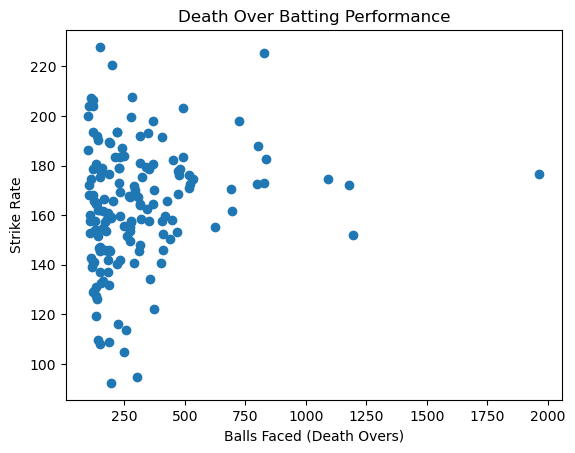

In [19]:
import matplotlib.pyplot as plt

plt.scatter(death_hitters["balls"], death_hitters["strike_rate"])

plt.xlabel("Balls Faced (Death Overs)")
plt.ylabel("Strike Rate")
plt.title("Death Over Batting Performance")

plt.show()

In [20]:
death_hitters["elite_finisher"] = (
    (death_hitters["balls"] >= 150) &
    (death_hitters["strike_rate"] >= 180)
)

## Bayesian Strike Rate Shrinkage

In [21]:
death_hitters = phase_batting[phase_batting["phase"] == "death"].copy()

In [22]:
league_sr = death_hitters["runs"].sum() / death_hitters["balls"].sum() * 100

In [23]:
k = 200

In [24]:
death_hitters["sr_bayes"] = (
    (death_hitters["balls"] / (death_hitters["balls"] + k)) * death_hitters["strike_rate"]
    + (k / (death_hitters["balls"] + k)) * league_sr
)

In [25]:
death_hitters.sort_values("sr_bayes", ascending=False).head(20)

,batter,phase,runs,balls,strike_rate,sr_bayes
95,AB de Villiers,death,1868,829,225.331725,212.260116
1541,RR Pant,death,1000,492,203.252033,190.196040
1898,T Stubbs,death,439,199,220.603015,189.262305
122,AD Russell,death,1432,724,197.790055,189.194437
1004,LS Livingstone,death,344,151,227.814570,188.078802
386,CH Gayle,death,581,280,207.500000,186.907624
746,JC Buttler,death,729,368,198.097826,184.006443
641,H Klaasen,death,553,277,199.638989,182.213123
1976,V Kohli,death,1507,803,187.671233,181.770349
1790,SV Samson,death,780,407,191.646192,180.585930


In [26]:
death_hitters["impact_score"] = death_hitters["sr_bayes"] * death_hitters["balls"]

In [27]:
death_hitters.sort_values("impact_score", ascending=False).head(20)

,batter,phase,runs,balls,strike_rate,sr_bayes,impact_score
1169,MS Dhoni,death,3468,1965,176.488550,174.787834,343458.092844
857,KA Pollard,death,2032,1180,172.203390,170.156275,200784.404539
872,KD Karthik,death,1904,1091,174.518790,171.971851,187621.289361
1478,RA Jadeja,death,1818,1195,152.133891,152.986136,182818.432371
95,AB de Villiers,death,1868,829,225.331725,212.260116,175963.636311
1502,RG Sharma,death,1527,837,182.437276,177.739305,148767.798496
1976,V Kohli,death,1507,803,187.671233,181.770349,145961.589846
656,HH Pandya,death,1430,827,172.914148,170.024985,140610.662556
122,AD Russell,death,1432,724,197.790055,189.194437,136976.772199
452,DA Miller,death,1381,800,172.625000,169.715660,135772.527637


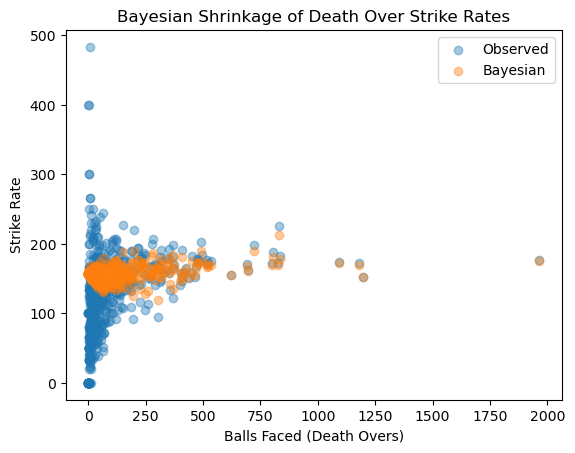

In [28]:
import matplotlib.pyplot as plt

plt.scatter(death_hitters["balls"], death_hitters["strike_rate"], alpha=0.4, label="Observed")

plt.scatter(death_hitters["balls"], death_hitters["sr_bayes"], alpha=0.4, label="Bayesian")

plt.xlabel("Balls Faced (Death Overs)")
plt.ylabel("Strike Rate")

plt.legend()
plt.title("Bayesian Shrinkage of Death Over Strike Rates")

plt.show()

## This only for active players 

In [29]:
player_seasons = df.groupby(["batter","date"]).size().reset_index()

In [30]:
df["year"] = pd.to_datetime(df["date"]).dt.year

In [31]:
latest_year = df.groupby("batter")["year"].max().reset_index()

latest_year.columns = ["batter","last_year"]

In [32]:
active_players = latest_year[latest_year["last_year"] >= 2023]

In [33]:
active_death_hitters = death_hitters.merge(
    active_players,
    on="batter"
)

## Batting Impact Score


In [34]:
active_death_hitters.sort_values("sr_bayes", ascending=False).head(20)

,batter,phase,runs,balls,strike_rate,sr_bayes,impact_score,last_year
203,RR Pant,death,1000,492,203.252033,190.196040,93576.451585,2025
243,T Stubbs,death,439,199,220.603015,189.262305,37663.198621,2025
9,AD Russell,death,1432,724,197.790055,189.194437,136976.772199,2025
117,LS Livingstone,death,344,151,227.814570,188.078802,28399.899121,2025
81,JC Buttler,death,729,368,198.097826,184.006443,67714.370974,2025
67,H Klaasen,death,553,277,199.638989,182.213123,50473.034999,2025
253,V Kohli,death,1507,803,187.671233,181.770349,145961.589846,2025
226,SV Samson,death,780,407,191.646192,180.585930,73498.473534,2025
245,TH David,death,676,350,193.142857,180.392108,63137.237893,2025
188,R Shepherd,death,161,66,243.939394,179.382179,11839.223797,2025


In [35]:
death_bowlers = phase_bowling[phase_bowling["phase"]=="death"]

death_bowlers.sort_values("economy").head(20)

,bowler,phase,runs,balls,wickets,economy
74,AC Gilchrist,death,0,1,1,0.000000
380,DJ Muthuswami,death,1,6,1,1.000000
1340,SE Rutherford,death,2,5,0,2.400000
1286,S Rana,death,2,4,0,3.000000
1250,S Badree,death,4,6,0,4.000000
1004,Naman Dhir,death,8,12,1,4.000000
968,N Burger,death,13,18,1,4.333333
266,C Bosch,death,9,12,1,4.500000
1409,SSB Magala,death,10,12,1,5.000000
1490,T Stubbs,death,5,6,0,5.000000


In [36]:
death_bowlers = phase_bowling[phase_bowling["phase"]=="death"].copy()

death_bowlers = death_bowlers[death_bowlers["balls"] >= 120]

In [37]:
league_econ = death_bowlers["runs"].sum() / (death_bowlers["balls"].sum()/6)

In [38]:
k = 200

death_bowlers["econ_bayes"] = (
    (death_bowlers["balls"]/(death_bowlers["balls"]+k))*death_bowlers["economy"]
    + (k/(death_bowlers["balls"]+k))*league_econ
)

In [39]:
death_bowlers["bowling_sr"] = death_bowlers["balls"] / death_bowlers["wickets"]

## Death Impact bowling score 
impact =
(league_econ − econ_bayes) × balls
+ wicket_weight × wickets

In [40]:
wicket_weight = 20

death_bowlers["impact_score"] = (
    (league_econ - death_bowlers["econ_bayes"]) * death_bowlers["balls"]
    + wicket_weight * death_bowlers["wickets"]
)

In [41]:
death_bowlers.sort_values("impact_score", ascending=False).head(20)

,bowler,phase,runs,balls,wickets,economy,econ_bayes,bowling_sr,impact_score
1358,SL Malinga,death,1526,1117,122,8.196956,8.443002,9.155738,3974.942865
602,JJ Bumrah,death,1882,1345,114,8.395539,8.579569,11.798246,3944.570371
1382,SP Narine,death,1314,1051,85,7.501427,7.871649,12.364706,3744.739334
365,DJ Bravo,death,2198,1385,130,9.522022,9.559264,10.653846,2957.196152
218,B Kumar,death,2326,1461,117,9.552361,9.584247,12.487179,2680.297373
425,DW Steyn,death,895,634,55,8.470032,8.793086,11.527273,1749.267784
290,CH Morris,death,959,646,64,8.907121,9.122262,10.093750,1728.909011
500,HV Patel,death,1434,840,93,10.242857,10.160994,9.032258,1571.185870
32,A Nehra,death,794,527,63,9.039848,9.253691,8.365079,1556.951967
1631,YS Chahal,death,1019,643,69,9.508554,9.581772,9.318841,1531.359474


In [42]:
latest_year_bowler = df.groupby("bowler")["year"].max().reset_index()

latest_year_bowler.columns = ["bowler","last_year"]

active_bowlers = latest_year_bowler[latest_year_bowler["last_year"] >= 2023]

In [43]:
active_death_bowlers = death_bowlers.merge(active_bowlers, on="bowler")

In [44]:
active_death_bowlers.sort_values("impact_score", ascending=False).head(20)

,bowler,phase,runs,balls,wickets,economy,econ_bayes,bowling_sr,impact_score,last_year
20,JJ Bumrah,death,1882,1345,114,8.395539,8.579569,11.798246,3944.570371,2025
59,SP Narine,death,1314,1051,85,7.501427,7.871649,12.364706,3744.739334,2025
8,B Kumar,death,2326,1461,117,9.552361,9.584247,12.487179,2680.297373,2025
15,HV Patel,death,1434,840,93,10.242857,10.160994,9.032258,1571.185870,2025
68,YS Chahal,death,1019,643,69,9.508554,9.581772,9.318841,1531.359474,2025
51,R Ashwin,death,834,601,40,8.326123,8.698419,15.025000,1472.367885,2025
55,Rashid Khan,death,822,576,43,8.562500,8.885868,13.395349,1396.428512,2025
23,K Rabada,death,1027,612,66,10.068627,10.006691,9.272727,1204.011256,2025
36,MM Sharma,death,1393,807,75,10.356877,10.249686,10.760000,1150.957736,2025
49,PP Chawla,death,657,444,41,8.878378,9.169928,10.829268,1107.374393,2024


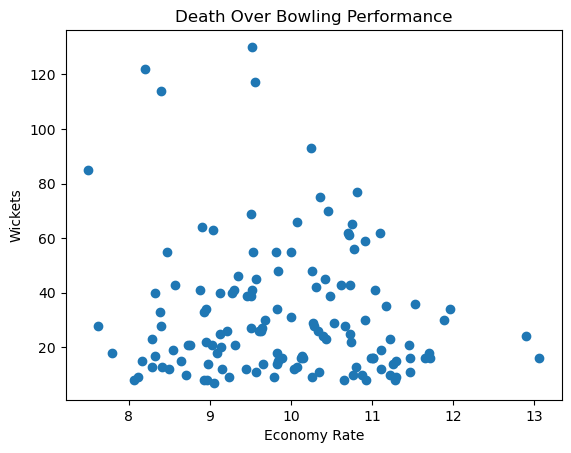

In [45]:
import matplotlib.pyplot as plt

plt.scatter(death_bowlers["economy"], death_bowlers["wickets"])

plt.xlabel("Economy Rate")
plt.ylabel("Wickets")

plt.title("Death Over Bowling Performance")

plt.show()

## For Middle and Powerplays

In [46]:
df["year"] = pd.to_datetime(df["date"]).dt.year

In [47]:
phase_batting = df.groupby(["batter", "phase"], observed=False).agg(
    runs=("runs_batter", "sum"),
    balls=("legal_ball", "sum")
).reset_index()

phase_batting["strike_rate"] = phase_batting["runs"] / phase_batting["balls"] * 100

phase_bowling = df.groupby(["bowler", "phase"], observed=False).agg(
    runs=("runs_total", "sum"),
    balls=("legal_ball", "sum"),
    wickets=("wicket", "sum")
).reset_index()

phase_bowling["economy"] = phase_bowling["runs"] / (phase_bowling["balls"] / 6)
phase_bowling["bowling_sr"] = phase_bowling["balls"] / phase_bowling["wickets"]

In [48]:
latest_year_batter = df.groupby("batter")["year"].max().reset_index()
latest_year_batter.columns = ["batter", "last_year"]

latest_year_bowler = df.groupby("bowler")["year"].max().reset_index()
latest_year_bowler.columns = ["bowler", "last_year"]

In [49]:
def get_batting_phase_rankings(phase_name, min_balls=100, k=200, active_since=2023):
    temp = phase_batting[phase_batting["phase"] == phase_name].copy()

    # minimum sample filter
    temp = temp[temp["balls"] >= min_balls].copy()

    # league strike rate for this phase
    league_sr = temp["runs"].sum() / temp["balls"].sum() * 100

    # Bayesian shrinkage
    temp["sr_bayes"] = (
        (temp["balls"] / (temp["balls"] + k)) * temp["strike_rate"]
        + (k / (temp["balls"] + k)) * league_sr
    )

    # impact score
    temp["impact_score"] = temp["sr_bayes"] * temp["balls"]

    # merge latest year
    temp = temp.merge(latest_year_batter, on="batter", how="left")

    # active subset
    active_temp = temp[temp["last_year"] >= active_since].copy()

    # rankings
    all_time = temp.sort_values("sr_bayes", ascending=False)
    active = active_temp.sort_values("sr_bayes", ascending=False)

    return all_time, active

In [50]:
def get_bowling_phase_rankings(phase_name, min_balls=120, k=200, wicket_weight=20, active_since=2023):
    temp = phase_bowling[phase_bowling["phase"] == phase_name].copy()

    # minimum sample filter
    temp = temp[temp["balls"] >= min_balls].copy()

    # league economy for this phase
    league_econ = temp["runs"].sum() / (temp["balls"].sum() / 6)

    # Bayesian shrinkage for economy
    temp["econ_bayes"] = (
        (temp["balls"] / (temp["balls"] + k)) * temp["economy"]
        + (k / (temp["balls"] + k)) * league_econ
    )

    # replace infinite bowling strike rates if wickets = 0
    temp["bowling_sr"] = temp["bowling_sr"].replace([float("inf")], pd.NA)

    # impact score
    temp["impact_score"] = (
        (league_econ - temp["econ_bayes"]) * temp["balls"]
        + wicket_weight * temp["wickets"]
    )

    # merge latest year
    temp = temp.merge(latest_year_bowler, on="bowler", how="left")

    # active subset
    active_temp = temp[temp["last_year"] >= active_since].copy()

    # rankings
    all_time = temp.sort_values("impact_score", ascending=False)
    active = active_temp.sort_values("impact_score", ascending=False)

    return all_time, active

In [51]:
pp_bat_all, pp_bat_active = get_batting_phase_rankings("powerplay", min_balls=150)
mid_bat_all, mid_bat_active = get_batting_phase_rankings("middle", min_balls=200)
death_bat_all, death_bat_active = get_batting_phase_rankings("death", min_balls=100)

In [52]:
print(pp_bat_all.head(20))
print(pp_bat_active.head(20))

print(mid_bat_all.head(20))
print(mid_bat_active.head(20))

print(death_bat_all.head(20))
print(death_bat_active.head(20))

              batter      phase  runs  balls  strike_rate    sr_bayes  \
100          TM Head  powerplay   673    365   184.383562  164.088142   
89         SP Narine  powerplay  1150    671   171.385991  161.205282   
66           PD Salt  powerplay   722    409   176.528117  160.278818   
7    Abhishek Sharma  powerplay  1018    629   161.844197  153.449699   
106      YBK Jaiswal  powerplay  1378    864   159.490741  153.392670   
68     Priyansh Arya  powerplay   384    217   176.958525  153.021104   
36       JM Bairstow  powerplay   944    623   151.524880  145.576914   
63    P Simran Singh  powerplay   872    583   149.571184  143.818391   
67           PP Shaw  powerplay  1347    917   146.892039  143.339123   
102         V Sehwag  powerplay  1593   1096   145.346715  142.522994   
58          MR Marsh  powerplay   518    347   149.279539  141.151372   
74      RD Rickelton  powerplay   297    193   153.886010  140.228500   
13           CA Lynn  powerplay   779    537   145.

In [53]:
pp_bowl_all, pp_bowl_active = get_bowling_phase_rankings("powerplay", min_balls=150)
mid_bowl_all, mid_bowl_active = get_bowling_phase_rankings("middle", min_balls=200)
death_bowl_all, death_bowl_active = get_bowling_phase_rankings("death", min_balls=120)

In [54]:
print(pp_bowl_all.head(20))
print(pp_bowl_active.head(20))

print(mid_bowl_all.head(20))
print(mid_bowl_active.head(20))

print(death_bowl_all.head(20))
print(death_bowl_active.head(20))

              bowler      phase  runs  balls  wickets   economy  bowling_sr  \
17           B Kumar  powerplay  2614   2339       85  6.705430   27.517647   
124   Sandeep Sharma  powerplay  2007   1690       66  7.125444   25.606061   
141           Z Khan  powerplay  1492   1292       58  6.928793   22.275862   
95           P Kumar  powerplay  1813   1572       44  6.919847   35.727273   
129         TA Boult  powerplay  1980   1612       73  7.369727   22.082192   
35          DW Steyn  powerplay  1229   1140       36  6.468421   31.666667   
116       SL Malinga  powerplay  1210   1110       40  6.540541   27.750000   
52         JJ Bumrah  powerplay  1314   1144       43  6.891608   26.604651   
102         R Ashwin  powerplay  1502   1252       54  7.198083   23.185185   
42          I Sharma  powerplay  1942   1521       60  7.660750   25.350000   
120        SP Narine  powerplay  1071    924       28  6.954545   33.000000   
71          M Morkel  powerplay  1107    906       3

In [55]:
output_dir = "/Users/piyushzaware/Documents/IPL_Data_Analysis/Data/"

pp_bat_all.to_csv(output_dir + "powerplay_batting_all_time.csv", index=False)
pp_bat_active.to_csv(output_dir + "powerplay_batting_active.csv", index=False)

mid_bat_all.to_csv(output_dir + "middle_batting_all_time.csv", index=False)
mid_bat_active.to_csv(output_dir + "middle_batting_active.csv", index=False)

death_bat_all.to_csv(output_dir + "death_batting_all_time.csv", index=False)
death_bat_active.to_csv(output_dir + "death_batting_active.csv", index=False)

pp_bowl_all.to_csv(output_dir + "powerplay_bowling_all_time.csv", index=False)
pp_bowl_active.to_csv(output_dir + "powerplay_bowling_active.csv", index=False)

mid_bowl_all.to_csv(output_dir + "middle_bowling_all_time.csv", index=False)
mid_bowl_active.to_csv(output_dir + "middle_bowling_active.csv", index=False)

death_bowl_all.to_csv(output_dir + "death_bowling_all_time.csv", index=False)
death_bowl_active.to_csv(output_dir + "death_bowling_active.csv", index=False)

## Building a Run Expectation Model

In [56]:
df["overs_remaining"] = 20 - df["over"] - (df["ball_in_over"] / 6)

df["wickets_remaining"] = 10 - df["innings_wickets_cum"]

## Estimate Expected Runs
5 overs left
7 wickets in hand
≈ 55 runs

In [57]:
run_expectancy = df.groupby(
    ["overs_remaining", "wickets_remaining"]
)["runs_total"].mean().reset_index()

## Run Value of Each Ball
actual runs − expected runs
4
run value = +2.8

In [58]:
df["run_value"] = df["runs_total"] - df["runs_total"].mean()

## Player Run Contribution

In [59]:
batter_impact = df.groupby("batter").agg(
    runs_added=("run_value","sum"),
    balls=("legal_ball","sum")
).reset_index()

In [60]:
bowler_impact = df.groupby("bowler").agg(
    runs_saved=("run_value","sum"),
    balls=("legal_ball","sum")
).reset_index()

## Convert Runs to Wins
~15 runs ≈ 1 win

In [61]:
batter_impact["wins_added"] = batter_impact["runs_added"] / 15

## Estimate Player Auction Value
wins_added = 3
1 win ≈ ₹8 crore
3 × 8 = ₹24 crore
expected auction value

## Build Auction Efficiency Metric
value_ratio = wins_added / auction_price

## Optimal ₹100 Crore Squad Allocation
2 powerplay batters
2 middle stabilizers
2 death hitters
3 pace bowlers
2 spin bowlers
2 all-rounders
₹100 Cr

Using ball-by-ball IPL data we estimate player impact relative to match context. We convert run contribution into win contribution and estimate the cost per win of each player archetype. This allows us to construct an optimal ₹100 crore roster allocation across batting and bowling phases.

## 